In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Create our data
grad_2022 = pd.read_csv('D:\GitHub\Intro-to-DS-AI-codes\exam practice\diemthithpt2022.csv')

<>:2: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:2: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\PC\AppData\Local\Temp\ipykernel_6992\3530181617.py:2: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  grad_2022 = pd.read_csv('D:\GitHub\Intro-to-DS-AI-codes\exam practice\diemthithpt2022.csv')


In [3]:
city = {
    '01': 'THÀNH PHỐ HÀ NỘI',
    '02': 'THÀNH PHỐ HỒ CHÍ MINH',
    '03': 'THÀNH PHỐ HẢI PHÒNG',
    '04': 'THÀNH PHỐ ĐÀ NẴNG',
    '05': 'TỈNH HÀ GIANG',
    '06': 'TỈNH CAO BẰNG',
    '07': 'TỈNH LAI CHÂU',
    '08': 'TỈNH LÀO CAI',
    '09': 'TỈNH TUYÊN QUANG',
    '10': 'TỈNH LẠNG SƠN',
    '11': 'TỈNH BẮC KẠN',
    '12': 'TỈNH THÁI NGUYÊN',
    '13': 'TỈNH YÊN BÁI',
    '14': 'TỈNH SƠN LA',
    '15': 'TỈNH PHÚ THỌ',
    '16': 'TỈNH VĨNH PHÚC',
    '17': 'TỈNH QUẢNG NINH',
    '18': 'TỈNH BẮC GIANG',
    '19': 'TỈNH BẮC NINH',
    '21': 'TỈNH HẢI DƯƠNG',
    '22': 'TỈNH HƯNG YÊN',
    '23': 'TỈNH HÒA BÌNH',
    '24': 'TỈNH HÀ NAM',
    '25': 'TỈNH NAM ĐỊNH',
    '26': 'TỈNH THÁI BÌNH',
    '27': 'TỈNH NINH BÌNH',
    '28': 'TỈNH THANH HÓA',
    '29': 'TỈNH NGHỆ AN',
    '30': 'TỈNH HÀ TĨNH',
    '31': 'TỈNH QUẢNG BÌNH',
    '32': 'TỈNH QUẢNG TRỊ',
    '33': 'TỈNH THỪA THIÊN HUẾ',
    '34': 'TỈNH QUẢNG NAM',
    '35': 'TỈNH QUẢNG NGÃI',
    '36': 'TỈNH KON TUM',
    '37': 'TỈNH BÌNH ĐỊNH',
    '38': 'TỈNH GIA LAI',
    '39': 'TỈNH PHÚ YÊN',
    '40': 'TỈNH ĐẮK LẮK',
    '41': 'TỈNH KHÁNH HÒA',
    '42': 'TỈNH LÂM ĐỒNG',
    '43': 'TỈNH BÌNH PHƯỚC',
    '44': 'TỈNH BÌNH DƯƠNG',
    '45': 'TỈNH NINH THUẬN',
    '46': 'TỈNH TÂY NINH',
    '47': 'TỈNH BÌNH THUẬN',
    '48': 'TỈNH ĐỒNG NAI',
    '49': 'TỈNH LONG AN',
    '50': 'TỈNH ĐỒNG THÁP',
    '51': 'TỈNH AN GIANG',
    '52': 'TỈNH BÀ RỊA VŨNG TÀU',
    '53': 'TỈNH TIỀN GIANG',
    '54': 'TỈNH KIÊN GIANG',
    '55': 'THÀNH PHỐ CẦN THƠ',
    '56': 'TỈNH BẾN TRE',
    '57': 'TỈNH VĨNH LONG',
    '58': 'TỈNH TRÀ VINH',
    '59': 'TỈNH SÓC TRĂNG',
    '60': 'TỈNH BẠC LIÊU',
    '61': 'TỈNH CÀ MAU',
    '62': 'TỈNH ĐIỆN BIÊN',
    '63' : 'TỈNH ĐĂK NÔNG',
    '64' : 'TỈNH HẬU GIANG'
}


In [4]:
# Convert id to str add 0 if len<8 (cuz id is len =8)
grad_2022['sbd'] = grad_2022['sbd'].astype(str).str.zfill(8)

# Map the students to their respective SGD
grad_2022['SGD'] = grad_2022['sbd'].str[:2].map(city)

In [5]:
# Some overview
grad_2022.head(10)

,sbd,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,SGD
0,01000001,3.6,5.00,4.0,NaN,NaN,NaN,2.75,6.00,8.75,THÀNH PHỐ HÀ NỘI
1,01000002,8.4,6.75,7.6,NaN,NaN,NaN,8.50,7.50,8.25,THÀNH PHỐ HÀ NỘI
2,01000003,5.8,7.50,5.0,NaN,NaN,NaN,7.25,5.50,8.75,THÀNH PHỐ HÀ NỘI
3,01000004,7.4,7.50,8.6,NaN,NaN,NaN,7.50,6.50,7.50,THÀNH PHỐ HÀ NỘI
4,01000005,7.2,8.50,9.0,NaN,NaN,NaN,8.00,8.50,8.25,THÀNH PHỐ HÀ NỘI
5,01000006,6.8,8.50,9.4,NaN,NaN,NaN,7.00,7.50,9.25,THÀNH PHỐ HÀ NỘI
6,01000007,7.2,6.00,5.0,NaN,NaN,NaN,8.00,7.50,9.00,THÀNH PHỐ HÀ NỘI
7,01000008,8.0,8.00,8.0,NaN,NaN,NaN,5.25,7.00,7.00,THÀNH PHỐ HÀ NỘI
8,01000009,2.6,5.25,NaN,NaN,NaN,NaN,5.25,6.75,NaN,THÀNH PHỐ HÀ NỘI
9,01000010,8.8,8.00,7.0,NaN,NaN,NaN,6.50,6.50,6.75,THÀNH PHỐ HÀ NỘI


In [16]:
from pathlib import Path

# Export to .csv file
output_path = Path(r'D:/Bao/Document/_VGU/_Semester 5/Compulsory Elective 1/grad_2022.csv')
grad_2022.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'Exported grad_2022 to: {output_path}')

Exported grad_2022 to: D:\Bao\Document\_VGU\_Semester 5\Compulsory Elective 1\grad_2022.csv


In [6]:
# Actual data we need
cols = ['toan', 'ngu_van', 'ngoai_ngu']
condition = grad_2022[cols].notna().all(axis=1)
data = grad_2022.loc[condition].copy()
print(data.shape)

# raw scores  for PCA
X = data[cols]

type(X)
X.head(5)

(866730, 11)


,toan,ngu_van,ngoai_ngu
0,3.6,5.00,4.0
1,8.4,6.75,7.6
2,5.8,7.50,5.0
3,7.4,7.50,8.6
4,7.2,8.50,9.0


In [7]:
# Scale data for PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [8]:
# Do PCA
pca = PCA(n_components=2) # Retain 2 principal components
pca_res = pca.fit_transform(scaled_data)

In [9]:
# Make the result into a data frame
pca_df = pd.DataFrame(pca_res)
pca_df= pca_df.rename(columns={0: 'PC1', 1: 'PC2'})

print(type(pca_df))
print(pca_df.shape)
pca_df.head(10)

<class 'pandas.core.frame.DataFrame'>
(866730, 2)


,PC1,PC2
0,-2.192316,-0.189406
1,1.473407,-0.824992
2,-0.025518,0.766048
3,1.698874,-0.324409
4,2.149249,0.291174
5,2.118113,0.294876
6,-0.092429,-0.519162
7,1.947784,-0.002412
8,1.948524,0.031553
9,0.904605,-0.065218


In [10]:
# Variance ratio (loading scores)
print(pca.explained_variance_ratio_)

[0.64082756 0.21658277]


In [11]:
# Final plot with 'sgd' attached
plot_df = pd.concat([data[['sbd', 'SGD']].reset_index(drop=True), pd.DataFrame(pca_res, columns=['PC1','PC2'])], axis=1)

# keep only HN and HCM rows
mask = plot_df['SGD'].isin(['TỈNH LÂM ĐỒNG', 'THÀNH PHỐ HỒ CHÍ MINH'])
plot_df = plot_df.loc[mask].reset_index(drop=True)

plot_df.head(10)

,sbd,SGD,PC1,PC2
0,02000001,THÀNH PHỐ HỒ CHÍ MINH,1.966967,-0.736410
1,02000002,THÀNH PHỐ HỒ CHÍ MINH,2.330508,-0.706005
2,02000003,THÀNH PHỐ HỒ CHÍ MINH,0.326250,-0.285461
3,02000004,THÀNH PHỐ HỒ CHÍ MINH,1.491290,-1.978541
4,02000005,THÀNH PHỐ HỒ CHÍ MINH,1.766801,-0.610446
5,02000006,THÀNH PHỐ HỒ CHÍ MINH,1.602866,-1.152400
6,02000007,THÀNH PHỐ HỒ CHÍ MINH,0.536149,0.216974
7,02000008,THÀNH PHỐ HỒ CHÍ MINH,1.662083,-0.042075
8,02000009,THÀNH PHỐ HỒ CHÍ MINH,1.428742,-0.365923
9,02000010,THÀNH PHỐ HỒ CHÍ MINH,1.451444,-0.578475


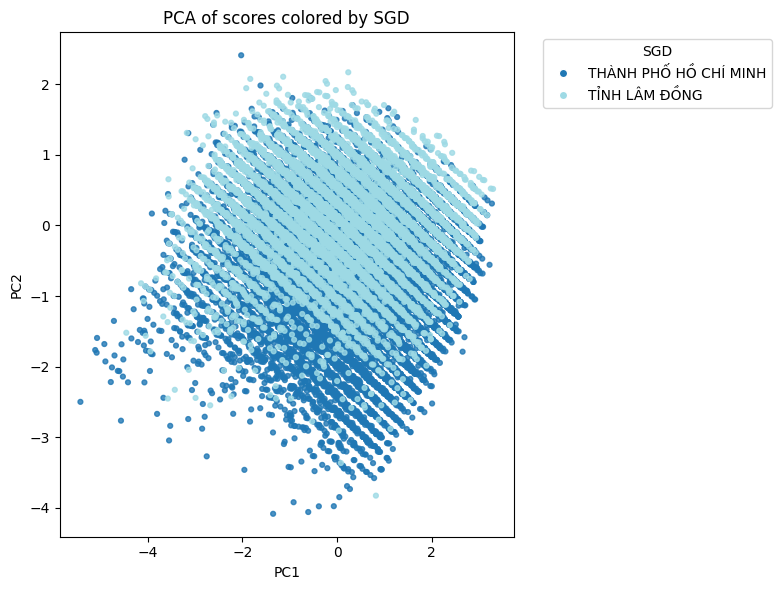

In [12]:
# Matplotlib scatter colored by SGD
plt.figure(figsize=(8, 6))
cats = plot_df['SGD'].astype('category')
codes = cats.cat.codes
cmap = plt.get_cmap('tab20', cats.cat.categories.size)

sc = plt.scatter(plot_df['PC1'], plot_df['PC2'], c=codes, cmap=cmap, s=12, alpha=0.8)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA of scores colored by SGD')

# Optional legend (can be large with many provinces)
handles = [plt.Line2D([0],[0], marker='o', color='w',
                      label=cat, markerfacecolor=cmap(i), markersize=6)
           for i, cat in enumerate(cats.cat.categories)]
plt.legend(handles=handles, title='SGD', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()